# Unidad 6 · Modelamiento de volatilidad

**Qué vas a aprender**
- Qué es la volatilidad, cómo se mide y cómo se anualiza.
- Por qué la volatilidad viene **en rachas** y cómo se contrasta (prueba ARCH).
- Ajustar e interpretar modelos **ARCH** y **GARCH**: persistencia, vida media, volatilidad de largo plazo.
- Comparar el GARCH con la **EWMA**, el modelo de una línea que usa el piloto, también fuera de la muestra.

**Qué tiene que ver con la app.** Esta unidad es el corazón del piloto. Su **volatilidad prevista**
es una EWMA con λ = 0,94, que es un caso particular del GARCH. Con ella decide cuánto tener en cripto:
$\min(1,\ \text{objetivo} / \text{volatilidad prevista})$. Al final reproduces la cifra exacta que da
el piloto para la cartera de ejemplo.

In [1]:
#@title Preparación: ejecuta esta celda primero (▶). Carga los precios de Binance.
# Es la misma en todos los cuadernos. Cómo se construye se explica en la Unidad 1.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})

ACTIVOS = ["BTC", "ETH", "SOL"]        # las monedas de la cartera de ejemplo del piloto
COLORES = {"BTC": "#F7931A", "ETH": "#627EEA", "SOL": "#9945FF"}
DESDE = "2020-01-01"                    # el piloto también mira desde 2020
HASTA = "2026-09-26"                    # fija las cifras del texto; None = hasta ayer
ANUAL = 365                             # las criptos cotizan todos los días del año
API = "https://data-api.binance.vision/api/v3/klines"   # api.binance.com bloquea Colab


def descargar(simbolo, desde=DESDE):
    """Velas diarias YA CERRADAS de SIMBOLO/USDT en Binance, 1000 por petición."""
    inicio = int(pd.Timestamp(desde, tz="UTC").timestamp() * 1000)
    filas = []
    while True:
        r = requests.get(API, params={"symbol": f"{simbolo}USDT", "interval": "1d",
                                      "startTime": inicio, "limit": 1000}, timeout=30)
        r.raise_for_status()
        lote = r.json()
        filas += lote
        if len(lote) < 1000:
            break
        inicio = lote[-1][0] + 1                      # la página siguiente empieza tras la última vela
    crudo = pd.DataFrame([f[:7] for f in filas],
                         columns=["apertura_ms", "open", "high", "low", "close", "volume", "cierre_ms"])
    crudo = crudo[crudo["cierre_ms"] < pd.Timestamp.now(tz="UTC").timestamp() * 1000]
    df = pd.DataFrame({"fecha": pd.to_datetime(crudo["apertura_ms"], unit="ms", utc=True)})
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = crudo[c].astype(float).to_numpy()
    return df.drop_duplicates("fecha").reset_index(drop=True)


def velas(simbolo):
    """Velas diarias del periodo de estudio: del CSV si ya está, si no de Binance (y lo guarda)."""
    archivo = f"{simbolo}USDT_1d.csv"
    hoy = pd.Timestamp.now(tz="UTC").normalize()
    fin = pd.Timestamp(HASTA, tz="UTC") if HASTA else hoy - pd.Timedelta(days=1)
    df = None
    if os.path.exists(archivo):
        df = pd.read_csv(archivo)
        df["fecha"] = pd.to_datetime(df["fecha"], utc=True)
    if df is None or df["fecha"].max() < fin:
        try:
            df = descargar(simbolo)
            df.to_csv(archivo, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
        except requests.RequestException as e:
            if df is None:
                raise RuntimeError(f"No pude descargar {simbolo} de Binance ({e}). Sube {archivo} "
                                   "(carpeta de datos de respaldo del curso) y repite.") from None
            print(f"Aviso: sin conexión con Binance; {archivo} llega solo al {df['fecha'].max():%d-%m-%Y}.")
    df = df[(df["fecha"] >= pd.Timestamp(DESDE, tz="UTC")) & (df["fecha"] <= fin)]
    return df.set_index("fecha")


def cierres(activos=ACTIVOS):
    """Cierres diarios, una columna por moneda: la tabla con la que trabaja el piloto."""
    return pd.DataFrame({a: velas(a)["close"] for a in activos})


print(f"Listo. Periodo de estudio: del {DESDE} al {HASTA or 'día de ayer'}.")

Listo. Periodo de estudio: del 2020-01-01 al 2026-09-26.


In [2]:
try:
    import arch                                     # Colab no lo trae instalado
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "arch"])
import warnings

from arch import arch_model
from statsmodels.stats.diagnostic import het_arch

warnings.filterwarnings("ignore", category=FutureWarning)

precios = cierres()
r = np.log(precios["BTC"]).diff().dropna()
r_pct = r * 100                                     # arch trabaja mejor con rendimientos en %
print(len(r), "rendimientos diarios de BTC")

2460 rendimientos diarios de BTC


## 1. Qué es la volatilidad

La **volatilidad** es la desviación típica de los rendimientos: cuánto se aleja, de media, un día
cualquiera de lo normal. Se suele expresar **anual**: la diaria por $\sqrt{365}$ (las varianzas de días
independientes se suman, y la desviación típica es su raíz).

Para tener una referencia: un índice de acciones amplio se mueve un 15-20 % al año. El perfil
**Prudente** del piloto (15 %) es eso: que tu cartera entera se mueva como la bolsa.

Volatilidad de BTC, toda la muestra: diaria 3.21% | anual 61.3%


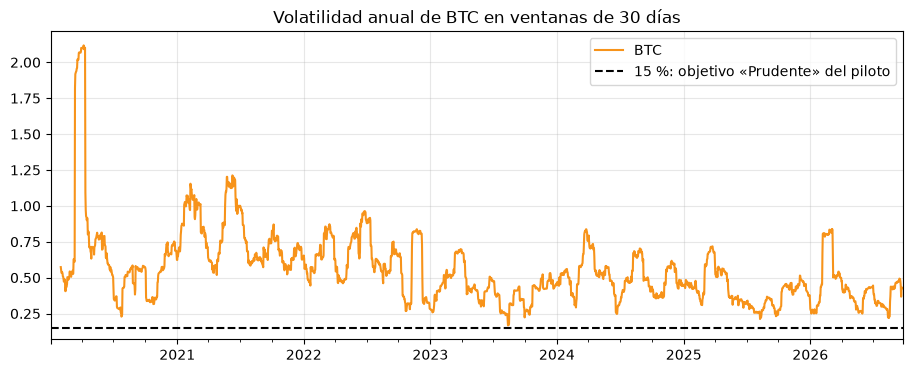

Por año: {2020: 0.81, 2021: 0.81, 2022: 0.64, 2023: 0.44, 2024: 0.53, 2025: 0.42, 2026: 0.46}


In [3]:
anual = r.std() * np.sqrt(ANUAL)
print(f"Volatilidad de BTC, toda la muestra: diaria {r.std():.2%} | anual {anual:.1%}")
realizada = r.rolling(30).std() * np.sqrt(ANUAL)
ax = realizada.plot(title="Volatilidad anual de BTC en ventanas de 30 días", color=COLORES["BTC"])
ax.axhline(0.15, color="black", linestyle="--", label="15 %: objetivo «Prudente» del piloto"); ax.legend(); ax.set_xlabel("")
plt.show()
print("Por año:", r.groupby(r.index.year).std().mul(np.sqrt(ANUAL)).round(2).to_dict())

La volatilidad de BTC **cambia mucho**: del 20 % en los meses tranquilos a más del 100 % en las crisis.
Un número para toda la muestra esconde lo más importante.

## 2. La volatilidad viene en rachas

Los días de grandes movimientos se agrupan. En la Unidad 5 vimos que los rendimientos **al cuadrado**
tienen autocorrelación. La **prueba ARCH-LM** de Engle lo contrasta formalmente: regresa $r_t^2$ sobre
sus 5 valores anteriores; si el R² es significativo, la varianza de hoy depende de la de días pasados.

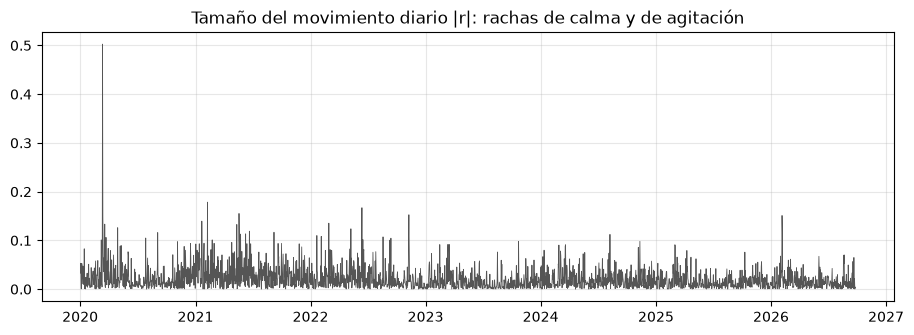

Prueba ARCH-LM con 5 rezagos: estadístico 28.3, p-valor 3.2e-05


In [4]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(r.abs(), color="#555555", linewidth=0.6); ax.set_title("Tamaño del movimiento diario |r|: rachas de calma y de agitación")
plt.show()
lm, p_lm, _, _ = het_arch(r - r.mean(), nlags=5)
print(f"Prueba ARCH-LM con 5 rezagos: estadístico {lm:.1f}, p-valor {p_lm:.1e}")

## 3. ARCH(1): la varianza de hoy depende del sobresalto de ayer

$$r_t = \mu + \varepsilon_t,\qquad \varepsilon_t = \sigma_t z_t,\qquad \sigma^2_t = \omega + \alpha\,\varepsilon^2_{t-1}$$

Un sobresalto ayer ($\varepsilon^2_{t-1}$ grande) sube la varianza prevista para hoy. Es el modelo de
Engle (1982), que le valió el Nobel.

In [5]:
m_arch = arch_model(r_pct, mean="Constant", vol="ARCH", p=1, dist="normal").fit(disp="off")
print(m_arch.params.round(4))
print(f"Log-verosimilitud {m_arch.loglikelihood:.1f} | AIC {m_arch.aic:.1f}")

mu          0.1103
omega       9.1576
alpha[1]    0.1131
Name: params, dtype: float64
Log-verosimilitud -6326.9 | AIC 12659.9


## 4. GARCH(1,1): la varianza también recuerda a la varianza

$$\sigma^2_t = \omega + \alpha\,\varepsilon^2_{t-1} + \beta\,\sigma^2_{t-1}$$

El término $\beta\,\sigma^2_{t-1}$ hace que la volatilidad tenga **memoria larga** con solo tres
parámetros. Tres cifras que se leen directamente:

| Cifra | Fórmula | Qué dice |
|---|---|---|
| **persistencia** | $\alpha + \beta$ | cuánto de la varianza de hoy pasa a mañana; cerca de 1 = mucha memoria |
| **vida media** | $\ln 0{,}5 / \ln(\alpha+\beta)$ | días que tarda un sobresalto en perder la mitad de su efecto |
| **volatilidad de largo plazo** | $\sqrt{\omega / (1-\alpha-\beta)}$ | hacia dónde vuelve la volatilidad |

Los rendimientos de cripto tienen colas gruesas, así que además del error **normal** se prueba uno con
distribución **t de Student**, cuyo parámetro ν mide el grosor de las colas (cuanto menor, más gruesas).

In [6]:
def resumen_garch(res, nombre):
    a, b, w = res.params["alpha[1]"], res.params["beta[1]"], res.params["omega"]
    pers = a + b
    integrado = pers > 0.995                        # persistencia 1 o casi: no hay nivel al que volver
    return {"modelo": nombre, "alpha": a, "beta": b, "persistencia": pers,
            "vida media (días)": np.nan if integrado else np.log(0.5) / np.log(pers),
            "vol. largo plazo": np.nan if integrado else np.sqrt(w / (1 - pers)) / 100 * np.sqrt(ANUAL),
            "nu": res.params.get("nu", np.nan), "AIC": res.aic}


g_normal = arch_model(r_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="normal").fit(disp="off")
g_t = arch_model(r_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
pd.DataFrame([resumen_garch(g_normal, "GARCH(1,1) normal"), resumen_garch(g_t, "GARCH(1,1) t")]).set_index("modelo").round(3)

,alpha,beta,persistencia,vida media (días),vol. largo plazo,nu,AIC
modelo,,,,,,,
"GARCH(1,1) normal",0.125,0.859,0.984,42.041,0.861,NaN,12346.930
"GARCH(1,1) t",0.071,0.929,1.000,NaN,NaN,3.133,11808.204


**Cómo se lee:**
- El GARCH mejora muchísimo el AIC del ARCH(1), y la versión con **t** mejora mucho a la normal: las
  colas gruesas importan. **ν ≈ 3** es una cola muy gruesa: los días extremos son mucho más frecuentes
  que con la normal.
- Con errores **normales**: β ≈ 0,86 y persistencia 0,98. La volatilidad de hoy es casi la de ayer, con
  un ajuste por el último sobresalto (α). Un sobresalto pierde la mitad de su efecto en unos 40 días, y
  la volatilidad tiende a volver a un 86 % anual.
- Con errores **t**, la persistencia llega a **1**, el límite que permite el modelo (en R, 0,999). Con
  persistencia 1 o casi no hay nivel de largo plazo ni vida media que tengan sentido (por eso salen
  vacías): cada sobresalto deja huella para siempre. Ese caso límite, con ω ≈ 0, tiene nombre: es la **EWMA** de la sección 6, la del
  piloto. Los datos de BTC no distinguen un GARCH de una EWMA.

## 5. La volatilidad que ve el modelo, y su pronóstico

El GARCH da una volatilidad **condicional** para cada día: la que esperaba con lo que sabía la víspera.
El GARCH normal, que sí tiene nivel de largo plazo, pronostica cómo volverá a él poco a poco.

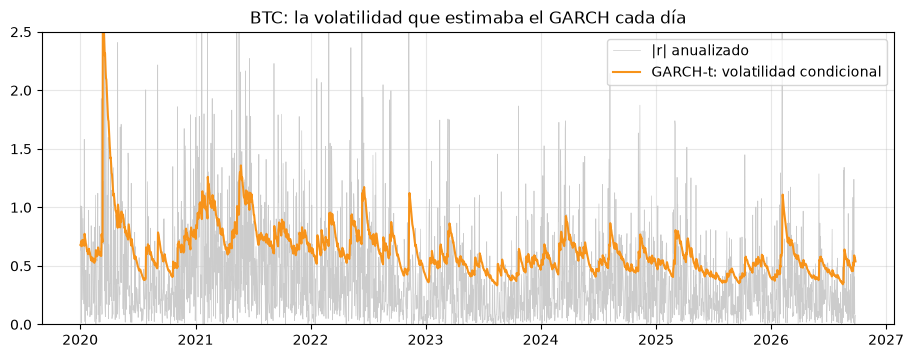

GARCH normal, volatilidad prevista: mañana 50.4% | dentro de 30 días 66.2% | dentro de 90 días 79.3% | largo plazo 86.1%


In [7]:
sigma_anual = g_t.conditional_volatility / 100 * np.sqrt(ANUAL)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(r.abs() * np.sqrt(ANUAL), color="#cccccc", linewidth=0.5, label="|r| anualizado")
ax.plot(sigma_anual, color=COLORES["BTC"], label="GARCH-t: volatilidad condicional")
ax.set_ylim(0, 2.5); ax.legend(); ax.set_title("BTC: la volatilidad que estimaba el GARCH cada día"); plt.show()

pron = g_normal.forecast(horizon=90, reindex=False).variance.iloc[0]
camino = np.sqrt(pron) / 100 * np.sqrt(ANUAL)
print(f"GARCH normal, volatilidad prevista: mañana {camino.iloc[0]:.1%} | dentro de 30 días {camino.iloc[29]:.1%}"
      f" | dentro de 90 días {camino.iloc[89]:.1%} | largo plazo {resumen_garch(g_normal, '')['vol. largo plazo']:.1%}")

## 6. EWMA: el GARCH de una línea que usa el piloto

La **EWMA** de RiskMetrics (J.P. Morgan, 1994) es un GARCH con $\omega = 0$, $\alpha = 1-\lambda$ y
$\beta = \lambda$:

$$\sigma^2_t = \lambda\,\sigma^2_{t-1} + (1-\lambda)\,r^2_{t-1},\qquad \lambda = 0{,}94$$

Persistencia exactamente 1: no tiene volatilidad de largo plazo ni hay que estimar nada. Sus ventajas
para una app: es una línea de código, no falla al estimar, y es estrictamente causal.

¿Pierde algo frente al GARCH? Se compara **fuera de la muestra**: parámetros del GARCH estimados hasta
2024 y fijos en 2025-2026. Cada día, cada modelo pronostica la varianza del día siguiente con lo que se
sabía al cierre. Dos medidas de error frente al rendimiento al cuadrado observado (menor es mejor):
- **MSE**: error cuadrático medio.
- **QLIKE**: $\ln\hat\sigma^2 + r^2/\hat\sigma^2$. Castiga sobre todo **quedarse corto**, que es el
  error caro en riesgo.

In [8]:
def ewma_varianza(x, lam=0.94, arranque=30):
    """Varianza EWMA del día SIGUIENTE, como el piloto: arranca con la varianza de los 30 primeros días."""
    v = np.var(x[:arranque])
    salida = np.empty(len(x))
    for i, xi in enumerate(x):
        v = lam * v + (1 - lam) * xi ** 2
        salida[i] = v                               # pronóstico para i + 1, con datos hasta i
    salida[:arranque] = np.nan
    return salida


corte = "2025-01-01"
modelo_e = arch_model(r_pct[r_pct.index < corte], mean="Constant", vol="GARCH", p=1, q=1, dist="t")
fijo = arch_model(r_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fix(modelo_e.fit(disp="off").params)

x = r_pct.to_numpy()
pron = pd.DataFrame({
    "GARCH-t": fijo.conditional_volatility.to_numpy() ** 2,               # σ²_t, con datos hasta t-1
    "EWMA 0,94": np.r_[np.nan, ewma_varianza(x)[:-1]],                    # desplazada: la de ayer pronostica hoy
    "30 días": pd.Series(x).rolling(30).var().shift(1).to_numpy(),
    "constante": np.full(len(x), np.var(x[r_pct.index < corte], ddof=1)),
}, index=r_pct.index)
real2 = r_pct ** 2
en_prueba = r_pct.index >= corte
pd.DataFrame({m: {"MSE": ((real2 - pron[m])[en_prueba] ** 2).mean(),
                  "QLIKE": (np.log(pron[m]) + real2 / pron[m])[en_prueba].mean()}
              for m in pron}).T.round(3)

,MSE,QLIKE
GARCH-t,194.052,2.639
"EWMA 0,94",188.492,2.624
30 días,194.356,2.704
constante,236.425,2.922


La EWMA queda incluso un poco **por delante** del GARCH en las dos medidas, y los dos mejoran claramente
a suponer una volatilidad constante. La ventana de 30 días se queda atrás en QLIKE: reacciona tarde a
los cambios. Por eso el piloto usa la EWMA: la misma calidad que un GARCH, sin estimar nada.

## 7. Caso aplicado: la volatilidad de BTC, ETH y SOL

Un GARCH(1,1) con errores t para cada moneda, con toda su historia del periodo de estudio.

In [9]:
filas = []
for a in ACTIVOS:
    ra = np.log(precios[a]).diff().dropna() * 100
    g = arch_model(ra, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
    fila = resumen_garch(g, a)
    fila["vol. prevista mañana"] = np.sqrt(g.forecast(horizon=1, reindex=False).variance.iloc[0, 0]) / 100 * np.sqrt(ANUAL)
    fila["vol. EWMA hoy"] = np.sqrt(ewma_varianza(ra.to_numpy())[-1]) / 100 * np.sqrt(ANUAL)
    filas.append(fila)
pd.DataFrame(filas).set_index("modelo").drop(columns="AIC").round(3)

,alpha,beta,persistencia,vida media (días),vol. largo plazo,nu,vol. prevista mañana,vol. EWMA hoy
modelo,,,,,,,,
BTC,0.071,0.929,1.00,NaN,NaN,3.133,0.524,0.446
ETH,0.098,0.902,1.00,NaN,NaN,3.412,0.588,0.514
SOL,0.115,0.865,0.98,34.65,1.27,4.883,0.812,0.696


- **SOL** es la más volátil hoy (70 % con la EWMA), y **BTC** la menos (45 %).
- **BTC y ETH** llegan a persistencia 1, como en la sección 4: se comportan como una EWMA. **SOL** tiene
  0,98, con una vida media de un mes y una volatilidad de largo plazo de más del 120 %.
- Las colas son gruesas en las tres (ν entre 3 y 5).
- El GARCH prevé para mañana algo más que la EWMA: con persistencia 1 y ω > 0, cada día suma un poco de
  varianza.

## 8. Así lo usa el piloto

Con la cartera de ejemplo (0,05 BTC, 1,2 ETH, 10 SOL y 500 USDT) y los cierres del 26-09-2026, el
piloto hace exactamente esto:

1. Calcula el **reparto** de la parte cripto según lo que vale cada moneda hoy.
2. Calcula el **rendimiento de esa mezcla** cada día del pasado (rendimientos log de los días comunes).
3. Le aplica la **EWMA** con λ = 0,94, arrancando con la varianza de los 30 primeros días, y la anualiza.
4. Recomienda en cripto $\min(1,\ 15\,\% / \sigma)$ del total.

In [10]:
unidades = pd.Series({"BTC": 0.05, "ETH": 1.2, "SOL": 10.0})
usdt = 500.0
comunes = precios.dropna()
valor = unidades * comunes.iloc[-1]
mezcla = valor / valor.sum()                                    # reparto de la parte cripto
lr = np.log(comunes).diff().dropna()
sigma = np.sqrt(ewma_varianza((lr @ mezcla).to_numpy())[-1] * ANUAL)
total = valor.sum() + usdt
parte = min(1, 0.15 / sigma)
print("Reparto de la parte cripto:", mezcla.round(3).to_dict())
print(f"Volatilidad prevista de la mezcla: {sigma:.2%}")
print(f"Recomendación: {parte:.1%} en cripto ({parte * total:,.0f} USDT de {total:,.0f});"
      f" hoy tiene el {valor.sum() / total:.1%} ({valor.sum():,.0f} USDT)")
print(f"Es decir, pasar unos {valor.sum() - parte * total:,.0f} USDT de cripto a USDT, repartidos según la mezcla")

Reparto de la parte cripto: {'BTC': 0.487, 'ETH': 0.373, 'SOL': 0.14}
Volatilidad prevista de la mezcla: 48.69%
Recomendación: 30.8% en cripto (2,825 USDT de 9,171); hoy tiene el 94.5% (8,671 USDT)
Es decir, pasar unos 5,846 USDT de cripto a USDT, repartidos según la mezcla


Son las cifras que muestra el piloto en **Hoy** para esta cartera con esos cierres (la app usa además
el precio de este momento para valorarla, así que las cifras de un día real se mueven un poco). Con una
volatilidad prevista del 49 %, para que **toda** la cartera se mueva un 15 % al año, la parte cripto
tiene que ser menos de un tercio.

## Ejercicios

1. **GJR-GARCH.** El sistema principal de la tesis usa un GJR-GARCH, que deja que las caídas suban la
   volatilidad más que las subidas: `arch_model(..., p=1, o=1, q=1, dist="t")`. ¿El término `gamma[1]`
   es positivo? ¿Mejora el AIC?
2. **λ.** Repite la comparación fuera de la muestra con λ = 0,97 y λ = 0,90. ¿Cuál gana en QLIKE?
3. **Otro objetivo.** Con la volatilidad de la sección 8, ¿qué parte en cripto recomendaría el perfil
   **Moderado** (25 %)? ¿Y el **Decidido** (40 %)?
4. **Tu cartera.** Cambia las unidades. ¿Qué cartera de tres monedas tiene la menor volatilidad
   prevista? ¿Por qué no es "todo en la menos volátil"?